# Modelado

Lucho May| 2026 <br>
Tombi by Kvi Baba

### Import Packages

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Modelado
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Boosting
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Interpretabilidad
import shap

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Tracking
import mlflow
import mlflow.sklearn

### Import dataset

In [2]:
df = pd.read_parquet(r"dataset_unificado_limpio.parquet")
df.drop(["precio_outlier","superficie_missing"], axis=1, inplace=True)
df_raw = df.copy()
df.head()

,id_aviso,tipo,zona_barrio,precio,superficie,ambientes,dormitorios,banios,antiguedad,cochera,balcon,pileta,fecha_publicacion,latitud,longitud
0,A-700480,Departamento,Belgrano,1267000.0,75.0,4,3,2,4.0,1,1,0,04/01/2025,-34.549646,-58.462834
1,A-220016,Departamento,Almagro,584000.0,39.0,2,1,1,6.0,0,0,0,15/01/2024,-34.608738,-58.439099
2,A-492142,Departamento,Flores,252000.0,35.0,2,1,1,23.0,1,0,0,07/03/2024,-34.622051,-58.456267
3,A-675147,Ph,Belgrano,546000.0,38.0,2,1,1,0.0,0,0,1,04/12/2024,-34.574757,-58.463758
4,A-307536,Departamento,Villa Urquiza,337000.0,33.0,1,0,1,2.0,0,1,0,25/02/2024,-34.554289,-58.486616


In [3]:
# Feature Engineering Espacial: Imputación inteligente de coordenadas por barrio
df['latitud'] = df.groupby('zona_barrio')['latitud'].transform(lambda x: x.fillna(x.median()))
df['longitud'] = df.groupby('zona_barrio')['longitud'].transform(lambda x: x.fillna(x.median()))
# Si aún quedan nulos, rellenamos con la mediana global
df['latitud'] = df['latitud'].fillna(df['latitud'].median())
df['longitud'] = df['longitud'].fillna(df['longitud'].median())

# Distancia al Centro (Obelisco) usando Haversine
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0 # Radio de la Tierra en km
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat / 2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2)**2
    return R * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))

df['distancia_centro'] = haversine(df['latitud'], df['longitud'], -34.6037, -58.3816)

In [4]:
# Definición de features y target
features_num = ['superficie', 'ambientes', 'dormitorios', 'banios', 'antiguedad', 'cochera', 'balcon', 'pileta', 'distancia_centro']
features_cat = ['tipo', 'zona_barrio']
target = 'precio'

X = df[features_num + features_cat]
y = df[target]

In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) # sparse_output=False ayuda a SHAP
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, features_num),
    ('cat', categorical_transformer, features_cat)
])

In [6]:
modelos = {
    "Baseline_Ridge": Ridge(alpha=10.0),
    "Random_Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=150, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    "XGBoost": XGBRegressor(n_estimators=150, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1)
}

In [7]:
# Configuración de MLflow
mlflow.set_experiment("Propiedata_Estimacion_Alquileres")

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'mape': 'neg_mean_absolute_percentage_error'}

resultados_modelos = {}

print("\nIniciando validación cruzada y tracking en MLflow...")

for nombre_modelo, estimador in modelos.items():
    pipeline_actual = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', estimador)
    ])
    
    with mlflow.start_run(run_name=nombre_modelo):
        # Logueamos parámetros básicos (si aplican)
        if hasattr(estimador, 'get_params'):
            params = {k: v for k, v in estimador.get_params().items() if k in ['n_estimators', 'learning_rate', 'max_depth', 'alpha']}
            mlflow.log_params(params)
            
        cv_results = cross_validate(pipeline_actual, X, y, cv=kf, scoring=scoring)
        
        # Extracción de métricas medias
        r2_mean = np.mean(cv_results['test_r2'])
        rmse_mean = -np.mean(cv_results['test_rmse'])
        mae_mean = -np.mean(cv_results['test_mae'])
        mape_mean = -np.mean(cv_results['test_mape'])
        
        # Logueamos métricas en MLflow
        mlflow.log_metrics({
            "R2_cv": r2_mean, 
            "RMSE_cv": rmse_mean, 
            "MAE_cv": mae_mean, 
            "MAPE_cv": mape_mean
        })
        
        # Logueamos el pipeline completo como artefacto
        mlflow.sklearn.log_model(pipeline_actual, f"modelo_{nombre_modelo}")
        
        resultados_modelos[nombre_modelo] = {'R2': r2_mean, 'RMSE': rmse_mean}
        
        print(f"--- {nombre_modelo} ---")
        print(f"R² CV: {r2_mean:.4f} | RMSE CV: {rmse_mean:.2f} | MAPE CV: {mape_mean:.4f}")

# Selección del mejor modelo
mejor_modelo_nombre = max(resultados_modelos, key=lambda k: resultados_modelos[k]['R2'])
print(f"\n🏆 Mejor modelo seleccionado para análisis final: {mejor_modelo_nombre} (R²: {resultados_modelos[mejor_modelo_nombre]['R2']:.4f})")


Iniciando validación cruzada y tracking en MLflow...


2026/05/05 23:26:02 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


--- Baseline_Ridge ---
R² CV: 0.2949 | RMSE CV: 3647233.01 | MAPE CV: 2.1452


2026/05/05 23:26:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


--- Random_Forest ---
R² CV: 0.3962 | RMSE CV: 3373331.87 | MAPE CV: 1.4251


2026/05/05 23:26:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


--- LightGBM ---
R² CV: 0.4988 | RMSE CV: 3075401.79 | MAPE CV: 1.3738


2026/05/05 23:27:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


--- XGBoost ---
R² CV: 0.5027 | RMSE CV: 3062495.88 | MAPE CV: 1.3878

🏆 Mejor modelo seleccionado para análisis final: XGBoost (R²: 0.5027)



Generando gráfica comparativa de modelos...


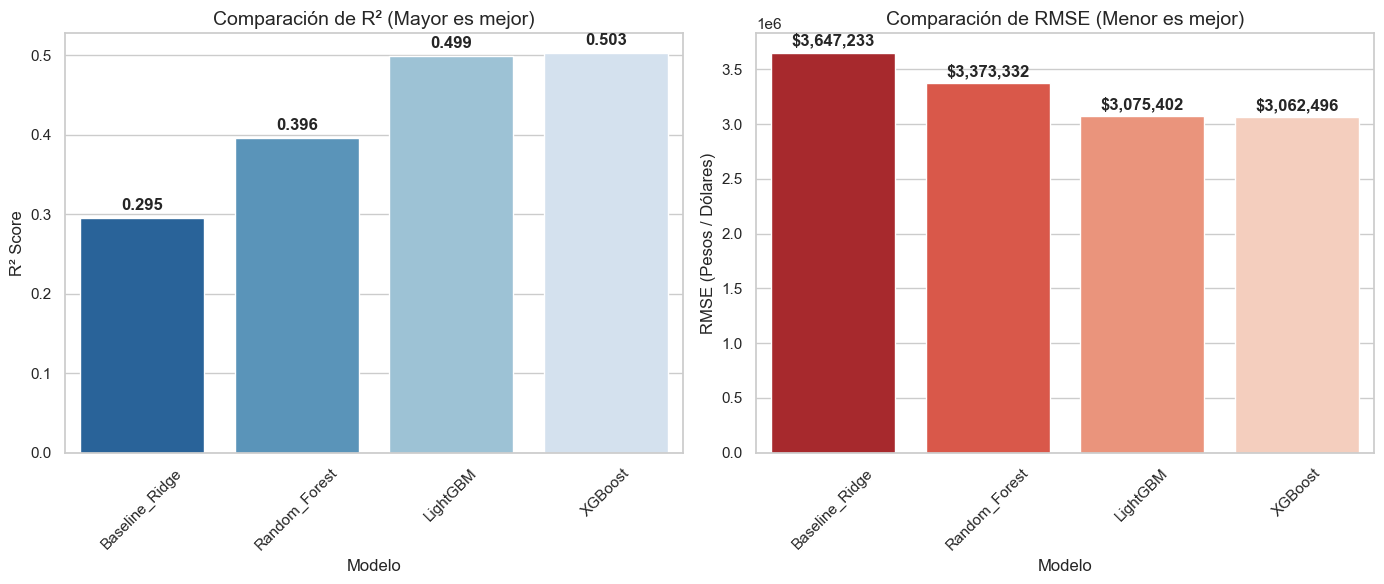

In [8]:
print("\nGenerando gráfica comparativa de modelos...")
res_df = pd.DataFrame([
    {'Modelo': k, 'R2': v['R2'], 'RMSE': v['RMSE']} 
    for k, v in resultados_modelos.items()
])

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de R2
sns.barplot(data=res_df, x='Modelo', y='R2', ax=axes[0], palette='Blues_r')
axes[0].set_title('Comparación de R² (Mayor es mejor)', fontsize=14)
axes[0].set_ylabel('R² Score')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(res_df['R2']):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha='center', fontweight='bold', fontsize=12)

# Gráfico de RMSE
sns.barplot(data=res_df, x='Modelo', y='RMSE', ax=axes[1], palette='Reds_r')
axes[1].set_title('Comparación de RMSE (Menor es mejor)', fontsize=14)
axes[1].set_ylabel('RMSE (Pesos / Dólares)')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(res_df['RMSE']):
    axes[1].text(i, v + (v * 0.02), f"${v:,.0f}", ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()


Generando explicabilidad con SHAP sobre el mejor modelo...


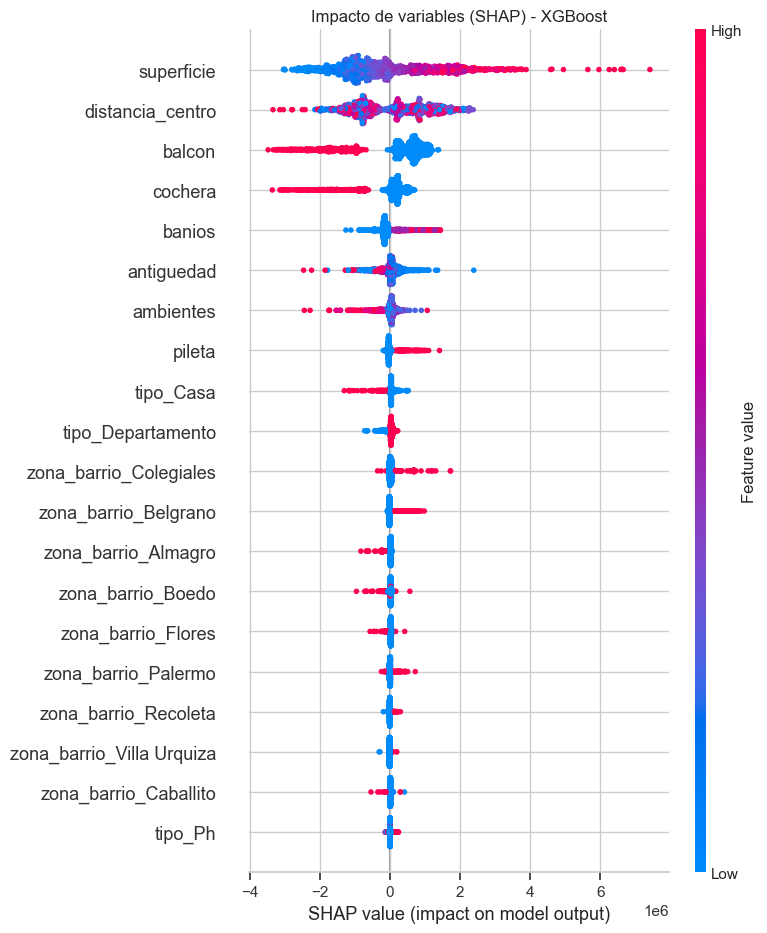


Top 5 Variables más importantes (Impacto SHAP medio absoluto):
superficie          1.153207e+06
distancia_centro    9.120306e+05
balcon              8.955593e+05
cochera             4.663858e+05
banios              2.535842e+05
dtype: float32


In [9]:
print("\nGenerando explicabilidad con SHAP sobre el mejor modelo...")

# Preparamos y entrenamos el mejor pipeline en un split tradicional para SHAP
mejor_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', modelos[mejor_modelo_nombre])
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
mejor_pipeline.fit(X_train, y_train)

# Extracción de componentes para SHAP
modelo_final = mejor_pipeline.named_steps['regressor']
prep_final = mejor_pipeline.named_steps['preprocessor']

# Nombres de features post-transformación
cat_encoder = prep_final.transformers_[1][1].named_steps['onehot']
feature_names_out = features_num + list(cat_encoder.get_feature_names_out(features_cat))

# Transformamos X_test
X_test_transformed = prep_final.transform(X_test)

# Lógica SHAP
if mejor_modelo_nombre in ["Random_Forest", "LightGBM", "XGBoost"]:
    explainer = shap.TreeExplainer(modelo_final)
    shap_values = explainer.shap_values(X_test_transformed)
    
    # Manejo de arrays para distintos motores
    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    # Plot SHAP Summary
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_out, show=False)
    plt.title(f"Impacto de variables (SHAP) - {mejor_modelo_nombre}")
    plt.tight_layout()
    plt.show()
    
    # Importancia numérica
    shap_sum = np.abs(shap_values).mean(axis=0)
    importancias_shap = pd.Series(shap_sum, index=feature_names_out).sort_values(ascending=False)
    print("\nTop 5 Variables más importantes (Impacto SHAP medio absoluto):")
    print(importancias_shap.head(5))
else:
    print("El modelo ganador es lineal. SHAP TreeExplainer no aplica, revisando coeficientes directos.")
    coefs = pd.Series(modelo_final.coef_, index=feature_names_out).sort_values(ascending=False)
    print(coefs.head(10))